# 01 — Pre-Processamento de Corpus

Pipeline base que transforma o **corpus bruto** em **`corpus_limpo.csv`** (granularidade unitaria, um documento por linha). E o primeiro passo de todo o framework — os modulos 02-05 consomem essa saida.

## Objetivo

Padronizar a entrada para que os 6 corpora (social, arj, folha, ag_news, reuters, tweets_bre2022) possam ser processados pelos modelos downstream sem codigo especifico por corpus.

## Etapas (linear, 7 passos)

| # | Passo | Proposito |
|---|---|---|
| 1 | Carga | Le CSV(s) de `data/raw/<corpus>/`, aplica `rename`/`drop`/`add_constants` |
| 2 | Dedup | Remove vazios e duplicatas exatas |
| 3 | Limpeza | Demojiza (PT/EN), colapsa caracteres repetidos. **Preserva URLs, @mentions, #hashtags** |
| 4 | Idioma | Mantem apenas docs do idioma-alvo (`langdetect`) |
| 5 | Comprimento | Remove docs muito curtos (chars + palavras configuraveis) |
| 6 | post_id | Garante chave primaria unica por documento |
| 7 | Export | Salva `corpus_limpo.csv` em `data/output/<corpus>/` |

## Principios de design

- **Conservador:** preserva sinal informativo (URLs marcam fontes, mentions identificam atores, hashtags marcam temas/movimentos)
- **Generalista:** o mesmo notebook trata os 6 corpora — diferencas (separador, encoding, rename, idioma, minimos) vivem no `params.yaml`
- **Granularidade `unit`:** um documento = uma linha. Sem agregacao mensal, sem roteamento curtos/longos, sem lematizacao aqui (lematizacao fica no 04, onde LDA precisa)

## O que este notebook NAO faz (por design)

- Lematizacao (feita em `_helpers.py` do 04-topic-modeling, so para LDA/STM)
- Agregacao mensal (eliminada — todos os modelos usam `unit`)
- Roteamento por tamanho de token (`route_documents` legado removido)
- Remocao de near-duplicates (so dedup exata — near-dup precisa de embeddings que nao temos aqui)

In [2]:
# === Setup ===
import re
import yaml
import numpy as np
import pandas as pd
from pathlib import Path
from langdetect import detect, DetectorFactory
import emoji
import matplotlib.pyplot as plt

# Seed do langdetect (determinismo — sem isso a deteccao varia entre execucoes)
DetectorFactory.seed = 0

# === Carrega configuracao do corpus ===
with open("../configs/params.yaml", encoding="utf-8") as f:
    params = yaml.safe_load(f)

# Escolha do corpus: vem de default_corpus em params.yaml; edite aqui para mudar
CORPUS = params.get("default_corpus", "arj")
# Opcoes: "social" | "arj" | "folha" | "ag_news" | "reuters" | "tweets_bre2022"

corpus_cfg = params["corpora"][CORPUS]

# === Le as chaves do params.yaml ===
TEXT_COL    = corpus_cfg["text_column"]                    # coluna com o texto principal
ID_COL      = corpus_cfg.get("id_column", "post_id")       # chave primaria (gerada se nao existir)
LANG_TARGET = corpus_cfg.get("language", "pt")             # "pt" | "en" — filtro de idioma
RAW_SUBDIR  = corpus_cfg["raw_subdir"]                     # subpasta em data/raw/
OUT_SUBDIR  = corpus_cfg.get("output_subdir", corpus_cfg.get("subdir", CORPUS))
MIN_CHARS   = corpus_cfg.get("min_doc_length", 30)         # comprimento minimo (chars)
MIN_WORDS   = corpus_cfg.get("min_words", 10)              # comprimento minimo (palavras)
EMOJI_MODE  = corpus_cfg.get("emoji_handling", "demojize_pt")  # demojize_pt | demojize_en
SEED        = params.get("seed", 42)

np.random.seed(SEED)

# Config de CSV (separador e encoding podem variar por corpus)
csv_cfg = corpus_cfg.get("csv", {})

# === Paths ===
RAW_DIR = Path("../data/raw") / RAW_SUBDIR
OUT_DIR = Path("../data/output") / OUT_SUBDIR
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Corpus      : {CORPUS}")
print(f"Idioma-alvo : {LANG_TARGET}")
print(f"Min chars   : {MIN_CHARS}    Min palavras: {MIN_WORDS}")
print(f"Emoji       : {EMOJI_MODE}")
print(f"Raw dir     : {RAW_DIR}")
print(f"Output dir  : {OUT_DIR}")

Corpus      : arj
Idioma-alvo : en
Min chars   : 50    Min palavras: 15
Emoji       : demojize_en
Raw dir     : ..\data\raw\arj
Output dir  : ..\data\output\arj


## 1. Carga do Corpus Bruto

Le todos os CSVs em `data/raw/<corpus>/` e os concatena. A configuracao por corpus vive em `params.yaml`:

| Chave | O que faz | Exemplo (social) |
|---|---|---|
| `csv.sep` | Separador de campo | `";"` (Instagram CSV) |
| `csv.encoding` | Encoding | `utf-8-sig` (remove BOM) |
| `rename` | Renomeia colunas para o schema padrao | `Message -> message`, `Post-ID -> post_id` |
| `drop` | Remove colunas irrelevantes | `["Reach per post", "Link"]` |
| `add_constants` | Injeta valores constantes (metadados) | `platform: instagram` |

> **Por que normalizar aqui?** Cada corpus tem seu schema (Instagram usa `Message`, Folha usa `Content`, AG News usa `text`). Apos esta celula, todos passam a ter pelo menos `message` (texto). O `post_id` sera atribuido na secao 6.

In [3]:
# === 1.1 Le todos os CSVs do corpus ===
csv_files = sorted(RAW_DIR.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError(
        f"Nenhum CSV em {RAW_DIR}.\n"
        f"Para ag_news ou reuters: ver CLAUDE.md (snippets de download).\n"
        f"Para os demais: confirme que o arquivo bruto esta em data/raw/{RAW_SUBDIR}/"
    )

sep = csv_cfg.get("sep", ",")
enc = csv_cfg.get("encoding", "utf-8")

# Le e concatena (suporta corpus particionado em multiplos CSVs)
frames = [pd.read_csv(f, sep=sep, encoding=enc) for f in csv_files]
df = pd.concat(frames, ignore_index=True)
print(f"Carregado: {len(csv_files)} arquivo(s), {len(df):,} linhas")

# === 1.2 Aplica rename do params.yaml ===
# Padroniza nomes de colunas (cada corpus tem o seu schema bruto).
if corpus_cfg.get("rename"):
    df = df.rename(columns=corpus_cfg["rename"])

# === 1.3 Remove colunas indesejadas ===
# Drop de colunas que nao serao usadas downstream (metadados ruidosos, links, etc).
drop_list = corpus_cfg.get("drop", corpus_cfg.get("drop_columns", []))
cols_to_drop = [c for c in drop_list if c in df.columns]
if cols_to_drop:
    df = df.drop(columns=cols_to_drop)
    print(f"Colunas removidas: {cols_to_drop}")

# === 1.4 Injeta constantes (metadados fixos do corpus) ===
# Ex: para social, add_constants: {platform: instagram}.
for col, val in (corpus_cfg.get("add_constants") or {}).items():
    if col not in df.columns:
        df[col] = val

print(f"\nShape final  : {df.shape}")
print(f"Colunas      : {list(df.columns)}")
df.head(3)

Carregado: 1 arquivo(s), 535 linhas

Shape final  : (535, 11)
Colunas      : ['doc_id', 'source_file', 'year', 'month', 'date_iso', 'page', 'title', 'actor', 'text_en', 'raw_metadata', 'source']


,doc_id,source_file,year,month,date_iso,page,title,actor,text_en,raw_metadata,source
0,1,Fichamento American Railroad Journal 1870-1872...,1870,1.0,1870-01-01,34,Michigan Central Railroad,Gestores,The gross earning show an increase over those ...,"Matéria: Michigan Central Railroad (sábado, 1 ...",american_railroad_journal
1,2,Fichamento American Railroad Journal 1870-1872...,1870,1.0,1870-01-01,36,Grand Trunk Railway of Canada,Gestores,The local rates upon the line are regulated by...,Matéria: Grand Trunk Railway of Canada (sábado...,american_railroad_journal
2,3,Fichamento American Railroad Journal 1870-1872...,1870,1.0,1870-01-15,68,The Darien Canal Project,Governo,But it remains stipuilated that the right whic...,"Matéria: The Darien Canal Project (Sábado, 15 ...",american_railroad_journal


## 2. Remocao de Vazios e Duplicatas Exatas

Duas limpezas conservadoras:

1. **Vazios**: linhas onde `message` e NaN ou string vazia. Geralmente erros de coleta.
2. **Duplicatas exatas**: dois ou mais documentos com texto byte-a-byte identico. Comum em:
   - Reposts/RTs nao marcados como tal
   - Boilerplate copiado entre artigos (ex: press releases replicados)
   - Bots em redes sociais

Mantemos a primeira ocorrencia (`keep="first"`).

> **Por que NAO removemos near-duplicates aqui?** Near-dup detection (cosine similarity > 0.95) precisa de embeddings, que so existem apos o modulo 02. Na pratica, BERTopic e robusto a near-dups. Se for critico, a etapa pode ser feita ex-post no 02-embeddings.

In [4]:
def remove_empty(df, col):
    """Remove linhas onde `col` esta vazia (NaN ou string em branco)."""
    mask = df[col].notna() & (df[col].astype(str).str.strip() != "")
    n_removed = len(df) - mask.sum()
    print(f"  Vazios removidos: {n_removed:,}")
    return df[mask].copy()


def remove_exact_duplicates(df, col):
    """Remove duplicatas exatas em `col`, mantendo a primeira ocorrencia."""
    before = len(df)
    df = df.drop_duplicates(subset=[col], keep="first").reset_index(drop=True)
    print(f"  Duplicatas exatas removidas: {before - len(df):,}")
    return df


df = remove_empty(df, TEXT_COL)
df = remove_exact_duplicates(df, TEXT_COL)
print(f"\nShape apos dedup: {df.shape}")

  Vazios removidos: 0
  Duplicatas exatas removidas: 18

Shape apos dedup: (517, 11)


## 3. Limpeza de Texto (conservadora)

Pipeline que **preserva** sinal informativo e **transforma** ruido em texto semantico.

### O que PRESERVAMOS (e por que)

| Elemento | Exemplo | Razao |
|---|---|---|
| **URLs** | `https://g1.globo.com/...` | Marca fonte/prova mobilizada no discurso |
| **@mentions** | `@raquellyra` | Identifica atores citados no documento |
| **#hashtags** | `#ForaBolsonaro` | Marca tema/movimento (insumo direto para topic modeling no 04) |

### O que TRANSFORMAMOS (e por que)

| Elemento | Antes | Depois | Razao |
|---|---|---|---|
| Emoji PT | "coracao vermelho" (U+2764) | `:coracao_vermelho:` | Tokenizadores tratam string semantica melhor que codepoint Unicode |
| Emoji EN | "coracao vermelho" (U+2764) | `:red_heart:` | Idem (para corpora em ingles) |
| Repeticao | `muuuito` | `muuito` | 3+ caracteres iguais -> 2 (preserva enfase mas reduz vocabulario inflado) |
| Espacos | `"a   b	c"` | `"a b c"` | Whitespace colapsado em um espaco |

> **Por que NUNCA "remove" emoji?** Em redes sociais brasileiras, emoji carrega sinal tematico forte (coracao_roxo = afeto, punho_cerrado = resistencia). `demojize` converte para uma string que os modelos downstream tratam como token normal.


In [5]:
def clean_text(text, emoji_handling="demojize_pt"):
    """
    Limpeza conservadora de texto.

    PRESERVA:
        - URLs (http/https/www)
        - @mentions
        - #hashtags (com o `#` intacto)

    TRANSFORMA:
        - Emoji  -> string semantica via `emoji.demojize` (idioma do corpus)
        - Chars repetidos 3+ vezes -> 2 (ex: "aaaa" -> "aa")
        - Whitespace multiplo -> 1 espaco

    Args:
        text: string a limpar (qualquer tipo, convertido para str)
        emoji_handling: "demojize_pt" (PT-BR) ou "demojize_en" (EN)

    Returns:
        Texto limpo (str).
    """
    text = str(text)

    # 1. Emoji -> texto semantico (idioma do corpus)
    if emoji_handling == "demojize_pt":
        text = emoji.demojize(text, language="pt")
    elif emoji_handling == "demojize_en":
        text = emoji.demojize(text, language="en")
    # Note: nao ha caminho "remove" — emoji sempre vira texto

    # 2. Colapsa repeticoes excessivas: "muuuito" -> "muuito"
    #    Regex: (.) captura um char; \1{2,} casa o mesmo char 2+ vezes mais
    #    (total >=3 ocorrencias seguidas). Substitui por 2 copias (\1\1).
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)

    # 3. Colapsa whitespace (espacos, tabs, newlines) em um unico espaco
    text = re.sub(r"\s+", " ", text).strip()

    return text


# === Aplica no corpus inteiro ===
# Guarda copia do texto bruto antes da limpeza (util para diagnostico/inspecao manual)
df["message_raw"] = df[TEXT_COL].astype(str)
df[TEXT_COL] = df[TEXT_COL].apply(lambda t: clean_text(t, EMOJI_MODE))

# === Diagnostico: mostra um par antes/depois ===
print(f"\n--- Exemplo (modo: {EMOJI_MODE}) ---")
print(f"ANTES : {df['message_raw'].iloc[0][:200]}")
print(f"DEPOIS: {df[TEXT_COL].iloc[0][:200]}")


--- Exemplo (modo: demojize_en) ---
ANTES : The gross earning show an increase over those of the corresponding six months of 1868, of $44,008.80; but the net earningshow a decrease of 473,788.84, owning to the fact that for five months, from th
DEPOIS: The gross earning show an increase over those of the corresponding six months of 1868, of $44,008.80; but the net earningshow a decrease of 473,788.84, owning to the fact that for five months, from th


## 4. Filtro de Idioma

Mantem apenas documentos no idioma-alvo (`params.yaml -> corpora.<corpus>.language`).

### Como funciona

A biblioteca `langdetect` (port Python do projeto language-detection da Google) classifica texto em 55 idiomas via n-gram profile. Funciona bem para docs com **5+ palavras**; abaixo disso, e instavel.

| Caso | Acao |
|---|---|
| `len(words) < 5` | Marca `None` (descartado no filtro) |
| Excecao do detector | Marca `None` (descartado no filtro) |
| Detectou `LANG_TARGET` | Mantem |
| Detectou outro idioma | Descarta |

### Por que isso e necessario

Corpus de redes sociais frequentemente tem ruido multilingual: comentarios em ingles, spam em outras linguas, bots multinacionais. Para um corpus PT-BR como `social`, o filtro tipicamente remove 5-15% das linhas.

### Visualizacao

O grafico abaixo mostra os top-10 idiomas detectados ANTES do filtro. A barra verde e o alvo (mantido); as cinzas serao descartadas.

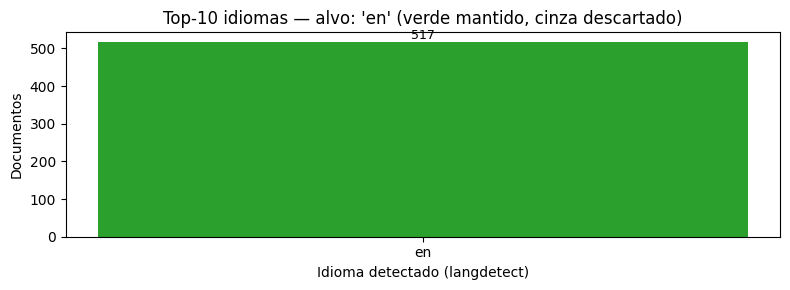


Removidos (idioma != 'en'): 0  (0.0%)
Shape apos filtro de idioma: (517, 12)


In [6]:
def detect_lang(text):
    """
    Detecta idioma do texto com `langdetect`.

    Returns:
        Codigo ISO-639-1 ("pt", "en", "es", ...) ou None se inconclusivo.
    """
    try:
        words = text.split()
        if len(words) < 5:
            # Texto curto demais — detector e instavel
            return None
        return detect(text)
    except Exception:
        # Caracteres invalidos, texto vazio apos clean, etc
        return None


# === Detecta idioma de cada documento ===
df["_lang"] = df[TEXT_COL].apply(detect_lang)

# === Visualiza distribuicao ANTES de filtrar ===
lang_counts = df["_lang"].fillna("(curto/erro)").value_counts().head(10)

fig, ax = plt.subplots(figsize=(8, 3))
colors = ["#2ca02c" if l == LANG_TARGET else "#7f7f7f" for l in lang_counts.index]
ax.bar(lang_counts.index, lang_counts.values, color=colors)
ax.set_xlabel("Idioma detectado (langdetect)")
ax.set_ylabel("Documentos")
ax.set_title(f"Top-10 idiomas — alvo: '{LANG_TARGET}' (verde mantido, cinza descartado)")
for i, v in enumerate(lang_counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / "preproc_language_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# === Filtra ===
before = len(df)
df = df[df["_lang"] == LANG_TARGET].drop(columns=["_lang"]).reset_index(drop=True)
removed = before - len(df)
pct = 100 * removed / before if before else 0
print(f"\nRemovidos (idioma != '{LANG_TARGET}'): {removed:,}  ({pct:.1f}%)")
print(f"Shape apos filtro de idioma: {df.shape}")

## 5. Filtro de Comprimento Minimo

Remove docs muito curtos para evitar dois problemas:

1. **LDA**: precisa de pelo menos algumas dezenas de tokens para estimar `theta` (distribuicao de topicos por documento). Docs com 5 palavras geram thetas instaveis.
2. **BERTopic**: docs muito curtos viram outliers no HDBSCAN — viram ruido no `topic = -1`.

Aplicamos DOIS filtros (ambos precisam ser satisfeitos):

| Filtro | Default | Customizavel em |
|---|---|---|
| `len(text)   >= MIN_CHARS` | 30 chars | `params.yaml -> min_doc_length` |
| `len(words)  >= MIN_WORDS` | 10 palavras | `params.yaml -> min_words` |

### Valores por corpus (em `params.yaml`)

| Corpus | min_chars | min_words | Justificativa |
|---|---|---|---|
| social | 30 | 10 | Posts de Instagram podem ser curtos |
| arj | 50 | 15 | Docs historicos sao maiores |
| folha | 100 | 30 | Artigos jornalisticos longos |
| ag_news | 30 | 5 | Headlines + descricao breve |
| reuters | 50 | 15 | News articles |
| tweets_bre2022 | 20 | 3 | Tweets sao naturalmente curtos |

### Visualizacao

Os dois histogramas abaixo mostram a distribuicao APOS o filtro. A linha vermelha pontilhada e o limiar minimo configurado.

Removidos (< 50 chars OU < 15 palavras): 0  (0.0%)
Shape final: (517, 12)


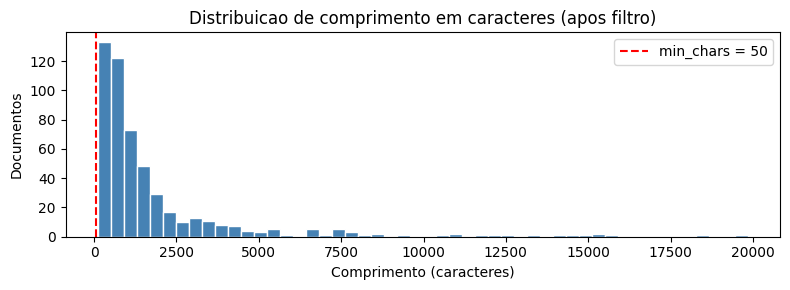

Caracteres - media: 1845.8, mediana: 915, p95: 7341


In [7]:
# === Aplica os dois filtros (AND logico) ===
before = len(df)

# Filtro 1: comprimento em caracteres
df = df[df[TEXT_COL].str.len() >= MIN_CHARS]
# Filtro 2: numero de palavras (split por whitespace)
df = df[df[TEXT_COL].str.split().str.len() >= MIN_WORDS]
df = df.reset_index(drop=True)

removed = before - len(df)
pct = 100 * removed / before if before else 0
print(f"Removidos (< {MIN_CHARS} chars OU < {MIN_WORDS} palavras): {removed:,}  ({pct:.1f}%)")
print(f"Shape final: {df.shape}")

# === Histograma de comprimento em caracteres (apos filtro) ===
lengths = df[TEXT_COL].str.len()
plt.figure(figsize=(8, 3))
plt.hist(lengths, bins=50, color="steelblue", edgecolor="white")
plt.axvline(MIN_CHARS, color="red", linestyle="--", label=f"min_chars = {MIN_CHARS}")
plt.xlabel("Comprimento (caracteres)")
plt.ylabel("Documentos")
plt.title("Distribuicao de comprimento em caracteres (apos filtro)")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "preproc_char_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Caracteres - media: {lengths.mean():.1f}, mediana: {lengths.median():.0f}, p95: {lengths.quantile(0.95):.0f}")

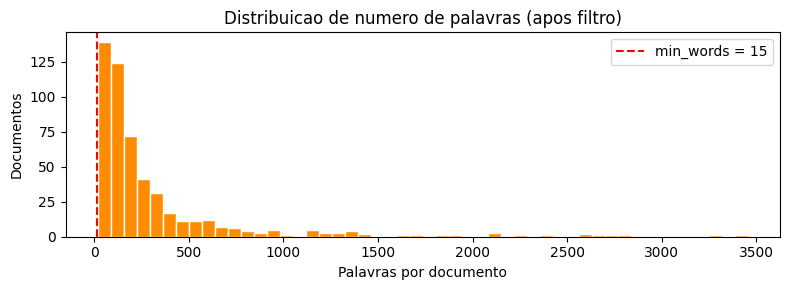

Palavras  - media: 316.0, mediana: 154, p95: 1250


In [8]:
# === Histograma de numero de palavras (apos filtro) ===
word_counts = df[TEXT_COL].str.split().str.len()
plt.figure(figsize=(8, 3))
plt.hist(word_counts, bins=50, color="darkorange", edgecolor="white")
plt.axvline(MIN_WORDS, color="red", linestyle="--", label=f"min_words = {MIN_WORDS}")
plt.xlabel("Palavras por documento")
plt.ylabel("Documentos")
plt.title("Distribuicao de numero de palavras (apos filtro)")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "preproc_word_count_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Palavras  - media: {word_counts.mean():.1f}, mediana: {word_counts.median():.0f}, p95: {word_counts.quantile(0.95):.0f}")

## 6. Atribuicao de `post_id`

O `post_id` e a **chave primaria** que permite cruzar tópicos (04) e sentimento (03) doc-a-doc. Sem ele, não da pra fazer merge:

```
docs com sentimento.csv  +  docs com topicos.csv  =>  merge on=post_id
```

### Regra

- **Se a coluna ja existe** (ex: `social` tem `Post-ID` que foi renomeado para `post_id`): converte para string e preserva
- **Se nao existe** (ex: ag_news): gera sequencial `post_0000`, `post_0001`, ...

### Garantia

Apos atribuir, a celula faz `assert df[id_col].nunique() == len(df)` — se houver duplicata de id, o pipeline falha imediatamente em vez de produzir resultados corrompidos downstream.


In [9]:
def assign_post_id(df, id_col, prefix="post"):
    """
    Garante que df tem uma coluna `id_col` com IDs unicos.

    - Se a coluna existe: converte para str (alguns corpora trazem int)
    - Se nao existe: gera `prefix_0000`, `prefix_0001`, ...
    - Verifica unicidade ao final (raise se houver duplicata)

    Returns:
        df com `id_col` garantido na primeira posicao se gerado.
    """
    if id_col in df.columns:
        df[id_col] = df[id_col].astype(str)
        print(f"post_id: usando coluna existente '{id_col}'")
    else:
        df.insert(0, id_col, [f"{prefix}_{i:04d}" for i in range(len(df))])
        print(f"post_id: gerado ({prefix}_0000 ... {prefix}_{len(df)-1:04d})")

    # Garantia: zero duplicatas (essencial para merges downstream)
    assert df[id_col].nunique() == len(df), \
        f"ERRO: post_id com duplicatas! ({len(df) - df[id_col].nunique()} repeticoes)"

    return df


df = assign_post_id(df, ID_COL)
df[[ID_COL, TEXT_COL]].head(3)

post_id: usando coluna existente 'doc_id'


,doc_id,text_en
0,1,The gross earning show an increase over those ...
1,2,The local rates upon the line are regulated by...
2,3,But it remains stipuilated that the right whic...


## 7. Exportacao

Salva `corpus_limpo.csv` em `data/output/<corpus>/`. Este arquivo e a entrada de TODOS os modulos downstream.

### Proximos passos (copia manual)

Apos rodar este notebook, copie o `corpus_limpo.csv` para os modulos que vao consumi-lo:

```powershell
# PowerShell (Windows)
$c = "social"  # ou outro corpus
Copy-Item "01-preprocessing/data/output/$c/corpus_limpo.csv" "02-embeddings/data/input/$c/" -Force
Copy-Item "01-preprocessing/data/output/$c/corpus_limpo.csv" "04-topic-modeling/data/input/$c/" -Force
```

### Quem consome o que

| Modulo | Le `corpus_limpo.csv` para... |
|---|---|
| `02-embeddings` | Gerar embeddings 1024d (Qwen3) e salvar `embeddings_*.npy` |
| `03-sentiment` | Le corpus + embeddings; classifica por anchors + LLM-Judge |
| `04-topic-modeling` | Le corpus + embeddings; treina BERTopic / LDA / STM |

In [10]:
# === Reordena colunas para uma saida limpa ===
# Coloca ID e texto na frente, depois message_raw, depois o resto
preferred_order = [ID_COL, TEXT_COL, "message_raw"]
remaining = [c for c in df.columns if c not in preferred_order]
final_cols = [c for c in preferred_order if c in df.columns] + remaining
df = df[final_cols]

# === Salva ===
out_path = OUT_DIR / "corpus_limpo.csv"
df.to_csv(out_path, index=False, encoding="utf-8")

print(f"Salvo    : {out_path}")
print(f"Shape    : {df.shape}")
print(f"Colunas  : {list(df.columns)}")
print(f"Tamanho  : {out_path.stat().st_size / 1e6:.1f} MB")
print(f"\nPrimeiras linhas:")
df.head(3)

Salvo    : ..\data\output\arj\corpus_limpo.csv
Shape    : (517, 12)
Colunas  : ['doc_id', 'text_en', 'message_raw', 'source_file', 'year', 'month', 'date_iso', 'page', 'title', 'actor', 'raw_metadata', 'source']
Tamanho  : 2.0 MB

Primeiras linhas:


,doc_id,text_en,message_raw,source_file,year,month,date_iso,page,title,actor,raw_metadata,source
0,1,The gross earning show an increase over those ...,The gross earning show an increase over those ...,Fichamento American Railroad Journal 1870-1872...,1870,1.0,1870-01-01,34,Michigan Central Railroad,Gestores,"Matéria: Michigan Central Railroad (sábado, 1 ...",american_railroad_journal
1,2,The local rates upon the line are regulated by...,The local rates upon the line are regulated by...,Fichamento American Railroad Journal 1870-1872...,1870,1.0,1870-01-01,36,Grand Trunk Railway of Canada,Gestores,Matéria: Grand Trunk Railway of Canada (sábado...,american_railroad_journal
2,3,But it remains stipuilated that the right whic...,But it remains stipuilated that the right whic...,Fichamento American Railroad Journal 1870-1872...,1870,1.0,1870-01-15,68,The Darien Canal Project,Governo,"Matéria: The Darien Canal Project (Sábado, 15 ...",american_railroad_journal
